<a href="https://colab.research.google.com/github/samreenfathima18/guvi-project2/blob/main/Data_Driven_Stock_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Project Title-Data-Driven Stock Analysis**

**STEP1: Data Extraction and Transformation**

In [ ]:
import os
import glob
import yaml
import pandas as pd

def extract_yaml_to_csv(yaml_directory, output_directory):

    if not os.path.exists(yaml_directory):
        print(f"❌ ERROR: The directory '{yaml_directory}' does not exist.")
        print("Please verify that your Google Drive is mounted using:")
        print("from google.colab import drive; drive.mount('/content/drive')")

        # Help user find the right path by listing what IS available
        parent_dir = os.path.dirname(yaml_directory.rstrip('/'))
        if os.path.exists(parent_dir):
            print(f"\nAvailable folders inside '{parent_dir}':", os.listdir(parent_dir))
        return

    os.makedirs(output_directory, exist_ok=True)
    all_records = []

    # FIX: Removed accidental spaces inside the glob patterns
    yaml_files = glob.glob(os.path.join(yaml_directory, "**/*.yaml"), recursive=True) + \
                 glob.glob(os.path.join(yaml_directory, "**/*.yml"), recursive=True)

    print(f"Found {len(yaml_files)} YAML files. Beginning extraction...")

    if len(yaml_files) == 0:
        # Check if files exist but have different extensions or case
        all_contents = os.listdir(yaml_directory) if os.path.exists(yaml_directory) else []
        print(f"Directory exists, but no .yaml/.yml found. Items directly inside folder: {all_contents[:10]}")
        return

    for file_path in yaml_files:
        with open(file_path, 'r') as f:
            try:
                content = yaml.safe_load(f)
                if not content or not isinstance(content, list):
                    continue

                for item in content:
                    if not isinstance(item, dict):
                        continue

                    symbol = item.get('Ticker')
                    raw_date = item.get('date')

                    if not symbol or not raw_date:
                        continue

                    record = {
                        'Date': raw_date,
                        'Symbol': str(symbol).strip(),
                        'Open': float(item.get('open', 0)),
                        'High': float(item.get('high', 0)),
                        'Low': float(item.get('low', 0)),
                        'Close': float(item.get('close', 0)),
                        'Volume': int(item.get('volume', 0))
                    }
                    all_records.append(record)

            except Exception as e:
                file_name = os.path.basename(file_path)
                print(f"Error processing file {file_name}: {e}")

    if not all_records:
        print("No records compiled. Please recheck your dataset status.")
        return

    df_master = pd.DataFrame(all_records)
    df_master['Date'] = pd.to_datetime(df_master['Date'], errors='coerce').dt.date
    df_master = df_master.sort_values(by=['Symbol', 'Date']).reset_index(drop=True)

    for symbol, df_symbol in df_master.groupby('Symbol'):
        clean_symbol_name = "".join([c for c in str(symbol) if c.isalnum() or c in ('_', '-')])
        csv_path = os.path.join(output_directory, f"{clean_symbol_name}.csv")
        df_symbol.to_csv(csv_path, index=False)

    print(f"\n✨ Success! Processed {len(all_records):,} total data rows.")
    print(f"📁 Generated {len(df_master['Symbol'].unique())} individual stock symbol CSV files inside your output directory.")

# Run the updated code
extract_yaml_to_csv('/content/drive/MyDrive/project2/project2', '/content/drive/MyDrive/Classroom/stock_csvs')


Found 284 YAML files. Beginning extraction...

✨ Success! Processed 14,200 total data rows.
📁 Generated 50 individual stock symbol CSV files inside your output directory.


In [ ]:
import os
import glob
import pandas as pd

def analyze_market_performance(df):

    print("\n📈 Executing Market Summary Calculations...")

    # Standardise date formatting and enforce chronological sort order
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values(by=['Symbol', 'Date']).reset_index(drop=True)

    performance_records = []

    # Calculate Individual Return Metrics per Stock Symbol
    for symbol, group in df.groupby('Symbol'):
        if group.empty:
            continue
        first_price = group['Close'].iloc[0]
        last_price = group['Close'].iloc[-1]

        # Formula: ((Close_Final - Close_Initial) / Close_Initial) * 100
        yearly_return = ((last_price - first_price) / first_price) * 100 if first_price > 0 else 0.0

        performance_records.append({
            'Symbol': symbol,
            'Initial_Price': round(first_price, 2),
            'Final_Price': round(last_price, 2),
            'Yearly_Return_%': round(yearly_return, 2)
        })

    df_perf = pd.DataFrame(performance_records)

    # Isolate the Top 10 Green and Loss Leader DataFrames
    top_10_green = df_perf.sort_values(by='Yearly_Return_%', ascending=False).head(10).reset_index(drop=True)
    top_10_loss = df_perf.sort_values(by='Yearly_Return_%', ascending=True).head(10).reset_index(drop=True)

    # Calculate Overall Structural Market Parameters
    total_assets = len(df_perf)
    green_count = len(df_perf[df_perf['Yearly_Return_%'] > 0])
    red_count = total_assets - green_count

    market_summary = {
        'Total_Stocks_Analyzed': total_assets,
        'Green_Stocks_Count': green_count,
        'Red_Stocks_Count': red_count,
        'Green_Stocks_Percentage': round((green_count / total_assets) * 100, 2) if total_assets > 0 else 0.0,
        'Red_Stocks_Percentage': round((red_count / total_assets) * 100, 2) if total_assets > 0 else 0.0,
        'Average_Market_Price': round(df['Close'].mean(), 2),
        'Average_Market_Volume': round(df['Volume'].mean(), 2)
    }
    df_summary = pd.DataFrame([market_summary])

    output_dir = '/content/drive/MyDrive/Classroom/analysis_outputs'
    os.makedirs(output_dir, exist_ok=True)

    top_10_green.to_csv(os.path.join(output_dir, 'top_10_green_stocks.csv'), index=False)
    top_10_loss.to_csv(os.path.join(output_dir, 'top_10_loss_stocks.csv'), index=False)
    df_summary.to_csv(os.path.join(output_dir, 'overall_market_summary.csv'), index=False)

    print("✨ Performance analysis completed and exported successfully to 'analysis_outputs' folder!")
    print(f"📊 Market Health: {market_summary['Green_Stocks_Percentage']}% Green vs {market_summary['Red_Stocks_Percentage']}% Red\n")

    return top_10_green, top_10_loss, df_summary

csv_directory = '/content/drive/MyDrive/Classroom/stock_csvs'

print(f"🔄 Rebuilding master dataset from: {csv_directory}")

csv_files = glob.glob(os.path.join(csv_directory, "*.csv"))

if not csv_files:
    print(f"❌ ERROR: No CSV files found in '{csv_directory}'.")
    print("Please make sure your extraction script ran successfully and saved the files there.")
else:
    print(f"📁 Found {len(csv_files)} CSV files. Combining data...")

    list_of_dfs = []
    for file_path in csv_files:
        df_stock = pd.read_csv(file_path)
        list_of_dfs.append(df_stock)

    df_master = pd.concat(list_of_dfs, ignore_index=True)
    print(f"✅ Rebuilt df_master successfully! Total rows: {len(df_master):,}")

    top_green_df, top_loss_df, market_summary_df = analyze_market_performance(df_master)

    # Preview results
    print("🟢 --- TOP 10 GREEN STOCKS  ---")
    print(top_green_df.head(10).to_string(index=False))
    print("🔴 --- TOP 10 LOSS STOCKS  ---")
    print(top_loss_df.head(10).to_string(index=False))


🔄 Rebuilding master dataset from: /content/drive/MyDrive/Classroom/stock_csvs
📁 Found 50 CSV files. Combining data...
✅ Rebuilt df_master successfully! Total rows: 14,200

📈 Executing Market Summary Calculations...
✨ Performance analysis completed and exported successfully to 'analysis_outputs' folder!
📊 Market Health: 90.0% Green vs 10.0% Red

🟢 --- TOP 10 GREEN STOCKS  ---
    Symbol  Initial_Price  Final_Price  Yearly_Return_%
     TRENT        2059.10      6652.80           223.09
       BEL         139.20       280.85           101.76
       M&M        1537.40      3012.95            95.98
BAJAJ-AUTO        5016.45      9481.65            89.01
BHARTIARTL         925.30      1569.30            69.60
 POWERGRID         199.55       336.95            68.85
      BPCL         170.68       285.85            67.48
HEROMOTOCO        3015.60      4794.10            58.98
 SUNPHARMA        1141.45      1795.30            57.28
   HCLTECH        1238.70      1898.40            53.26
🔴 --- 

**1. Volatility Analysis**

🔄 Processing all market metrics (Performance & Volatility)...

💾 Success! CSV files saved to: /content/drive/MyDrive/Classroom/analysis_outputs
   ↳ top_10_most_volatile_stocks.csv
   ↳ top_10_green_stocks.csv
   ↳ top_10_loss_stocks.csv
🖼️ Success! Volatility chart saved as PNG image to: /content/drive/MyDrive/Classroom/analysis_outputs/top_10_volatility_chart.png



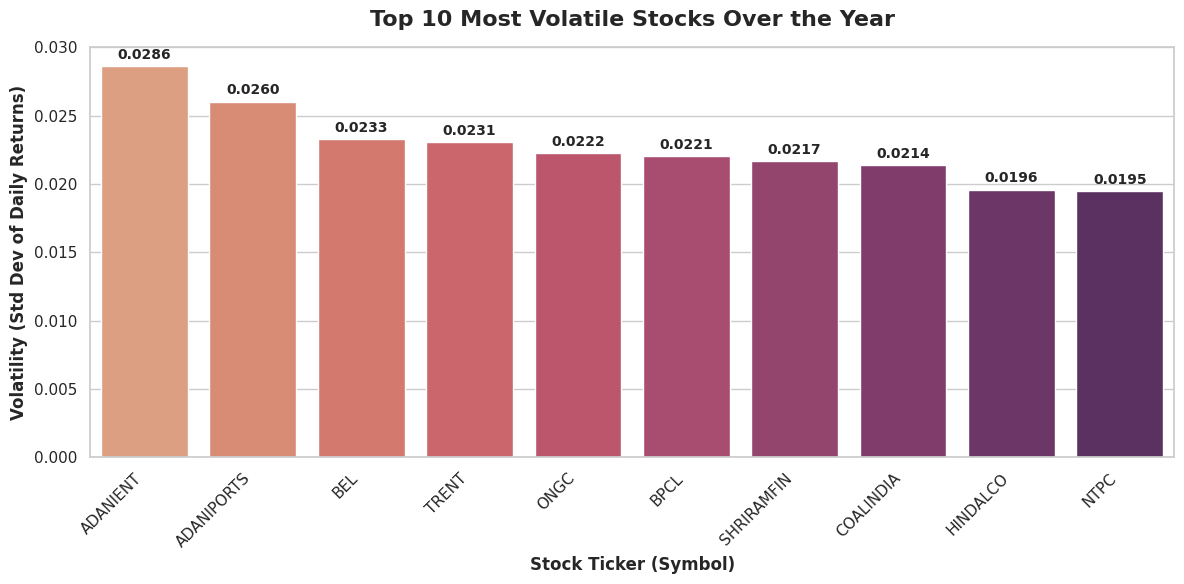

In [ ]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
csv_directory = '/content/drive/MyDrive/Classroom/stock_csvs'
output_directory = '/content/drive/MyDrive/Classroom/analysis_outputs'
os.makedirs(output_directory, exist_ok=True)

csv_files = glob.glob(os.path.join(csv_directory, "*.csv"))

if not csv_files:
    print(f"❌ ERROR: No CSV files found in '{csv_directory}'.")
else:
    # 2. Combine all asset data
    list_of_dfs = []
    for file_path in csv_files:
        list_of_dfs.append(pd.read_csv(file_path))

    df_master = pd.concat(list_of_dfs, ignore_index=True)
    df_master = df_master.sort_values(by=['Symbol', 'Date']).reset_index(drop=True)

    print("🔄 Processing all market metrics (Performance & Volatility)...")

    # ==========================================
    # ANALYSIS PART A: YEARLY RETURNS
    # ==========================================
    performance_records = []
    for symbol, group in df_master.groupby('Symbol'):
        if group.empty:
            continue
        first_price = group['Close'].iloc[0]
        last_price = group['Close'].iloc[-1]

        yearly_return = ((last_price - first_price) / first_price) * 100 if first_price > 0 else 0.0
        performance_records.append({
            'Symbol': symbol,
            'Initial_Price': first_price,
            'Current_Price': last_price,
            'Yearly_Return_%': round(yearly_return, 2)
        })

    df_performance = pd.DataFrame(performance_records)
    top_10_green = df_performance.sort_values(by='Yearly_Return_%', ascending=False).head(10).reset_index(drop=True)
    top_10_loss = df_performance.sort_values(by='Yearly_Return_%', ascending=True).head(10).reset_index(drop=True)

    # ==========================================
    # ANALYSIS PART B: VOLATILITY
    # ==========================================
    df_master['Daily_Return'] = df_master.groupby('Symbol')['Close'].pct_change()
    volatility_series = df_master.groupby('Symbol')['Daily_Return'].std()

    df_volatility = volatility_series.reset_index()
    df_volatility.columns = ['Symbol', 'Volatility_StdDev']
    df_volatility = df_volatility.dropna().sort_values(by='Volatility_StdDev', ascending=False)
    top_10_volatile = df_volatility.head(10).reset_index(drop=True)

    # ==========================================
    # 💾 SAVE ALL OUTPUT TABLES AS CSV FILES
    # ==========================================
    path_volatility = os.path.join(output_directory, 'top_10_most_volatile_stocks.csv')
    path_green = os.path.join(output_directory, 'top_10_green_stocks.csv')
    path_loss = os.path.join(output_directory, 'top_10_loss_stocks.csv')

    top_10_volatile.to_csv(path_volatility, index=False)
    top_10_green.to_csv(path_green, index=False)
    top_10_loss.to_csv(path_loss, index=False)

    print(f"\n💾 Success! CSV files saved to: {output_directory}")
    print(f"   ↳ {os.path.basename(path_volatility)}")
    print(f"   ↳ {os.path.basename(path_green)}")
    print(f"   ↳ {os.path.basename(path_loss)}")

    # ==========================================
    # 🎨 VISUALIZATION AND IMAGE STORAGE
    # ==========================================
    plt.figure(figsize=(12, 6))
    sns.set_theme(style="whitegrid")

    ax = sns.barplot(
        x='Symbol',
        y='Volatility_StdDev',
        data=top_10_volatile,
        palette='flare',
        hue='Symbol',
        legend=False
    )

    plt.title('Top 10 Most Volatile Stocks Over the Year', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Stock Ticker (Symbol)', fontsize=12, fontweight='bold')
    plt.ylabel('Volatility (Std Dev of Daily Returns)', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45, ha='right')

    for p in ax.patches:
        ax.annotate(
            f"{p.get_height():.4f}",
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center', va='center',
            xytext=(0, 8),
            textcoords='offset points',
            fontsize=10, fontweight='bold'
        )

    plt.tight_layout()

    # 💾 SAVE PLOT TO DRIVE BEFORE SHOWING IT
    chart_output_path = os.path.join(output_directory, 'top_10_volatility_chart.png')
    plt.savefig(chart_output_path, dpi=300)
    print(f"🖼️ Success! Volatility chart saved as PNG image to: {chart_output_path}\n")

    plt.show()


**Cumulative Return Analysis**

🔄 Processing chronological compounding returns...
💾 Success! Timeline records saved to: /content/drive/MyDrive/Classroom/analysis_outputs/top_5_cumulative_returns_timeline.csv
🖼️ Success! Line chart saved as PNG image to: /content/drive/MyDrive/Classroom/analysis_outputs/top_5_cumulative_returns_chart.png



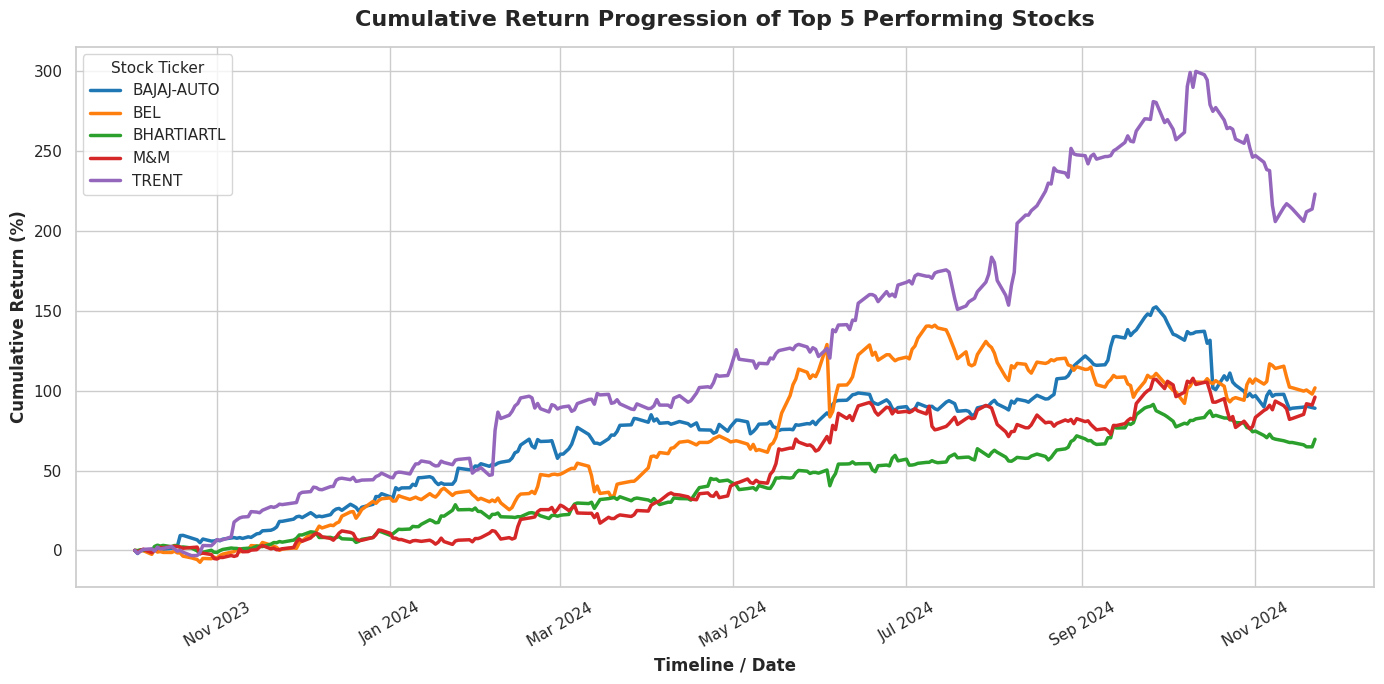

In [ ]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setup file directories
csv_directory = '/content/drive/MyDrive/Classroom/stock_csvs'
output_directory = '/content/drive/MyDrive/Classroom/analysis_outputs'
os.makedirs(output_directory, exist_ok=True)

csv_files = glob.glob(os.path.join(csv_directory, "*.csv"))

if not csv_files:
    print(f"❌ ERROR: No CSV files found in '{csv_directory}'.")
else:
    list_of_dfs = []
    for file_path in csv_files:
        list_of_dfs.append(pd.read_csv(file_path))

    df_master = pd.concat(list_of_dfs, ignore_index=True)

    df_master['Date'] = pd.to_datetime(df_master['Date'])
    df_master = df_master.sort_values(by=['Symbol', 'Date']).reset_index(drop=True)

    print("🔄 Processing chronological compounding returns...")

    df_master['Daily_Return'] = df_master.groupby('Symbol')['Close'].pct_change().fillna(0)

    # Native vectorized compound multiplication without index mismatch errors
    df_master['Cumulative_Return_%'] = (
        df_master.groupby('Symbol')['Daily_Return']
        .transform(lambda x: (x + 1).cumprod() - 1) * 100
    )

    # Identifies the Top 5 performing stocks based on final cumulative return value
    final_returns = df_master.groupby('Symbol').last().reset_index()
    top_5_symbols = final_returns.sort_values(by='Cumulative_Return_%', ascending=False).head(5)['Symbol'].tolist()

    # Filter dataset for top 5 assets
    df_top_5_trends = df_master[df_master['Symbol'].isin(top_5_symbols)].copy()


    path_cumulative = os.path.join(output_directory, 'top_5_cumulative_returns_timeline.csv')
    df_top_5_trends.to_csv(path_cumulative, index=False)
    print(f"💾 Success! Timeline records saved to: {path_cumulative}")

    plt.figure(figsize=(14, 7))
    sns.set_theme(style="whitegrid")

    sns.lineplot(
        data=df_top_5_trends,
        x='Date',
        y='Cumulative_Return_%',
        hue='Symbol',
        palette='tab10',
        linewidth=2.5
    )

    plt.title('Cumulative Return Progression of Top 5 Performing Stocks', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Timeline / Date', fontsize=12, fontweight='bold')
    plt.ylabel('Cumulative Return (%)', fontsize=12, fontweight='bold')
    plt.legend(title='Stock Ticker', title_fontsize='11', loc='upper left', frameon=True)

    plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
    plt.xticks(rotation=30)
    plt.tight_layout()

    # 💾 SAVE CHART TO DRIVE BEFORE DISPLAY
    chart_output_path = os.path.join(output_directory, 'top_5_cumulative_returns_chart.png')
    plt.savefig(chart_output_path, dpi=300)
    print(f"🖼️ Success! Line chart saved as PNG image to: {chart_output_path}\n")

    plt.show()




**Sector Performance**

🔄 Processing performance calculations...

🏢 === SECTOR-WISE PERFORMANCE SUMMARY ===
         Sector  Yearly_Return_%
      RETAILING           113.31
        DEFENCE           101.76
        TELECOM            69.60
          POWER            60.18
    AUTOMOBILES            47.63
         MINING            41.85
       SOFTWARE            38.28
         CEMENT            36.97
         ENERGY            36.56
      ALUMINIUM            35.87
       TEXTILES            35.78
PHARMACEUTICALS            31.38
  MISCELLANEOUS            21.85
          STEEL            19.22
    ENGINEERING            17.25
      INSURANCE            11.77
        FINANCE            11.58
        BANKING             6.59
           FMCG             5.55
 FOOD & TOBACCO             4.32
         PAINTS           -21.94

💾 Success! Sector summaries saved to: /content/drive/MyDrive/Classroom/analysis_outputs/sector_wise_performance_summary.csv
🖼️ Success! Sector chart saved as PNG image to: /content/drive/My

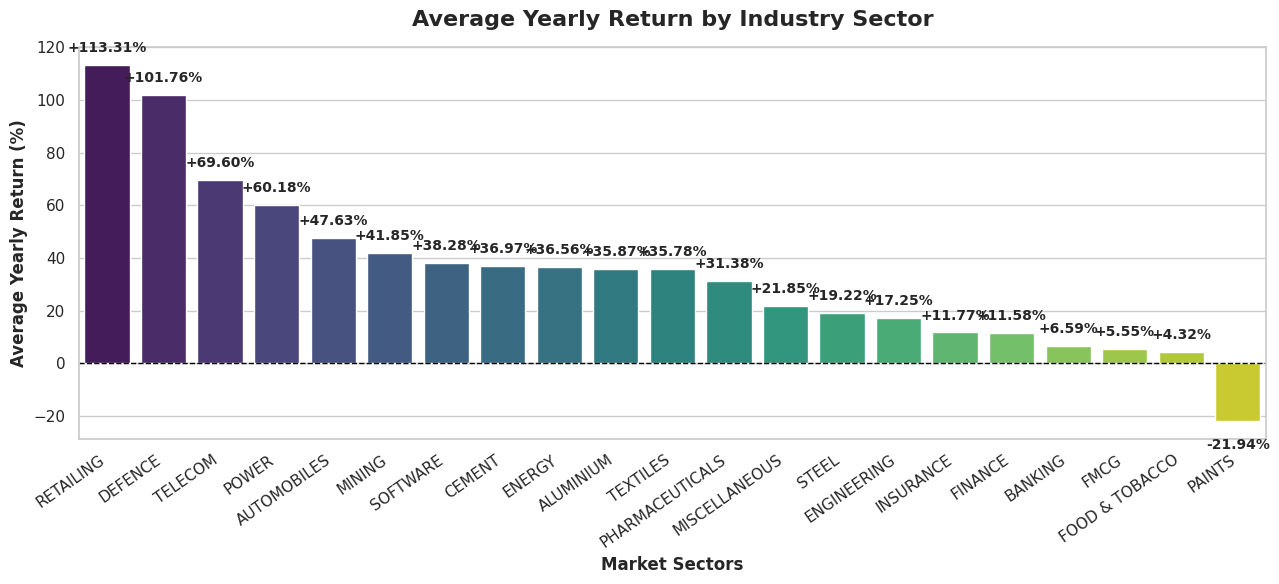

In [ ]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

csv_directory = '/content/drive/MyDrive/Classroom/stock_csvs'
output_directory = '/content/drive/MyDrive/Classroom/analysis_outputs'
sector_csv_path = '/content/drive/MyDrive/Classroom/analysis_outputs/sector.csv'

os.makedirs(output_directory, exist_ok=True)

csv_files = glob.glob(os.path.join(csv_directory, "*.csv"))

if not csv_files or not os.path.exists(sector_csv_path):
    print(f"❌ ERROR: Verify that stock CSVs exist and sector path '{sector_csv_path}' is correct.")
else:
    list_of_dfs = []
    for file_path in csv_files:
        list_of_dfs.append(pd.read_csv(file_path))
    df_master = pd.concat(list_of_dfs, ignore_index=True)
    df_master = df_master.sort_values(by=['Symbol', 'Date']).reset_index(drop=True)

    print("🔄 Processing performance calculations...")

    performance_records = []
    for symbol, group in df_master.groupby('Symbol'):
        if group.empty:
            continue
        first_price = group['Close'].iloc[0]
        last_price = group['Close'].iloc[-1]

        yearly_return = ((last_price - first_price) / first_price) * 100 if first_price > 0 else 0.0
        performance_records.append({
            'Symbol': symbol,
            'Yearly_Return_%': yearly_return
        })
    df_stock_perf = pd.DataFrame(performance_records)
    df_sectors = pd.read_csv(sector_csv_path)
    df_sectors.columns = [col.strip().capitalize() for col in df_sectors.columns]
    df_stock_perf['Symbol'] = df_stock_perf['Symbol'].str.strip()
    df_sectors['Symbol'] = df_sectors['Symbol'].str.strip()

    df_merged = pd.merge(df_stock_perf, df_sectors, on='Symbol', how='inner')

    if df_merged.empty:
        print("⚠️ WARNING: Merged dataset is empty. Check if stock ticker symbols match your sector CSV column values exactly.")
    else:
        df_sector_perf = (
            df_merged.groupby('Sector')['Yearly_Return_%']
            .mean()
            .reset_index()
            .sort_values(by='Yearly_Return_%', ascending=False)
            .reset_index(drop=True)
        )
        df_sector_perf['Yearly_Return_%'] = df_sector_perf['Yearly_Return_%'].round(2)

        print("\n🏢 === SECTOR-WISE PERFORMANCE SUMMARY ===")
        print(df_sector_perf.to_string(index=False))

        path_sector_out = os.path.join(output_directory, 'sector_wise_performance_summary.csv')
        df_sector_perf.to_csv(path_sector_out, index=False)
        print(f"\n💾 Success! Sector summaries saved to: {path_sector_out}")
        plt.figure(figsize=(13, 6))
        sns.set_theme(style="whitegrid")
        ax = sns.barplot(
            x='Sector',
            y='Yearly_Return_%',
            data=df_sector_perf,
            palette='viridis',
            hue='Sector',
            legend=False
        )

        plt.title('Average Yearly Return by Industry Sector', fontsize=16, fontweight='bold', pad=15)
        plt.xlabel('Market Sectors', fontsize=12, fontweight='bold')
        plt.ylabel('Average Yearly Return (%)', fontsize=12, fontweight='bold')
        plt.xticks(rotation=35, ha='right')

        plt.axhline(0, color='black', linewidth=1, linestyle='--')

        for p in ax.patches:
            height = p.get_height()
            va_align = 'bottom' if height >= 0 else 'top'
            xy_offset = (0, 7) if height >= 0 else (0, -12)

            ax.annotate(
                f"{height:+.2f}%",
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va=va_align,
                xytext=xy_offset,
                textcoords='offset points',
                fontsize=10, fontweight='bold'
            )

        plt.tight_layout()

        chart_sector_path = os.path.join(output_directory, 'sector_performance_chart.png')
        plt.savefig(chart_sector_path, dpi=300)
        print(f"🖼️ Success! Sector chart saved as PNG image to: {chart_sector_path}\n")

        plt.show()


**Stock Price Correlation**



🔄 Processing daily performance movements...
💾 Success! Complete correlation matrix saved to: /content/drive/MyDrive/Classroom/analysis_outputs/market_stock_correlation_matrix.csv
🖼️ Success! Heatmap visual saved as PNG image to: /content/drive/MyDrive/Classroom/analysis_outputs/stock_correlation_heatmap.png



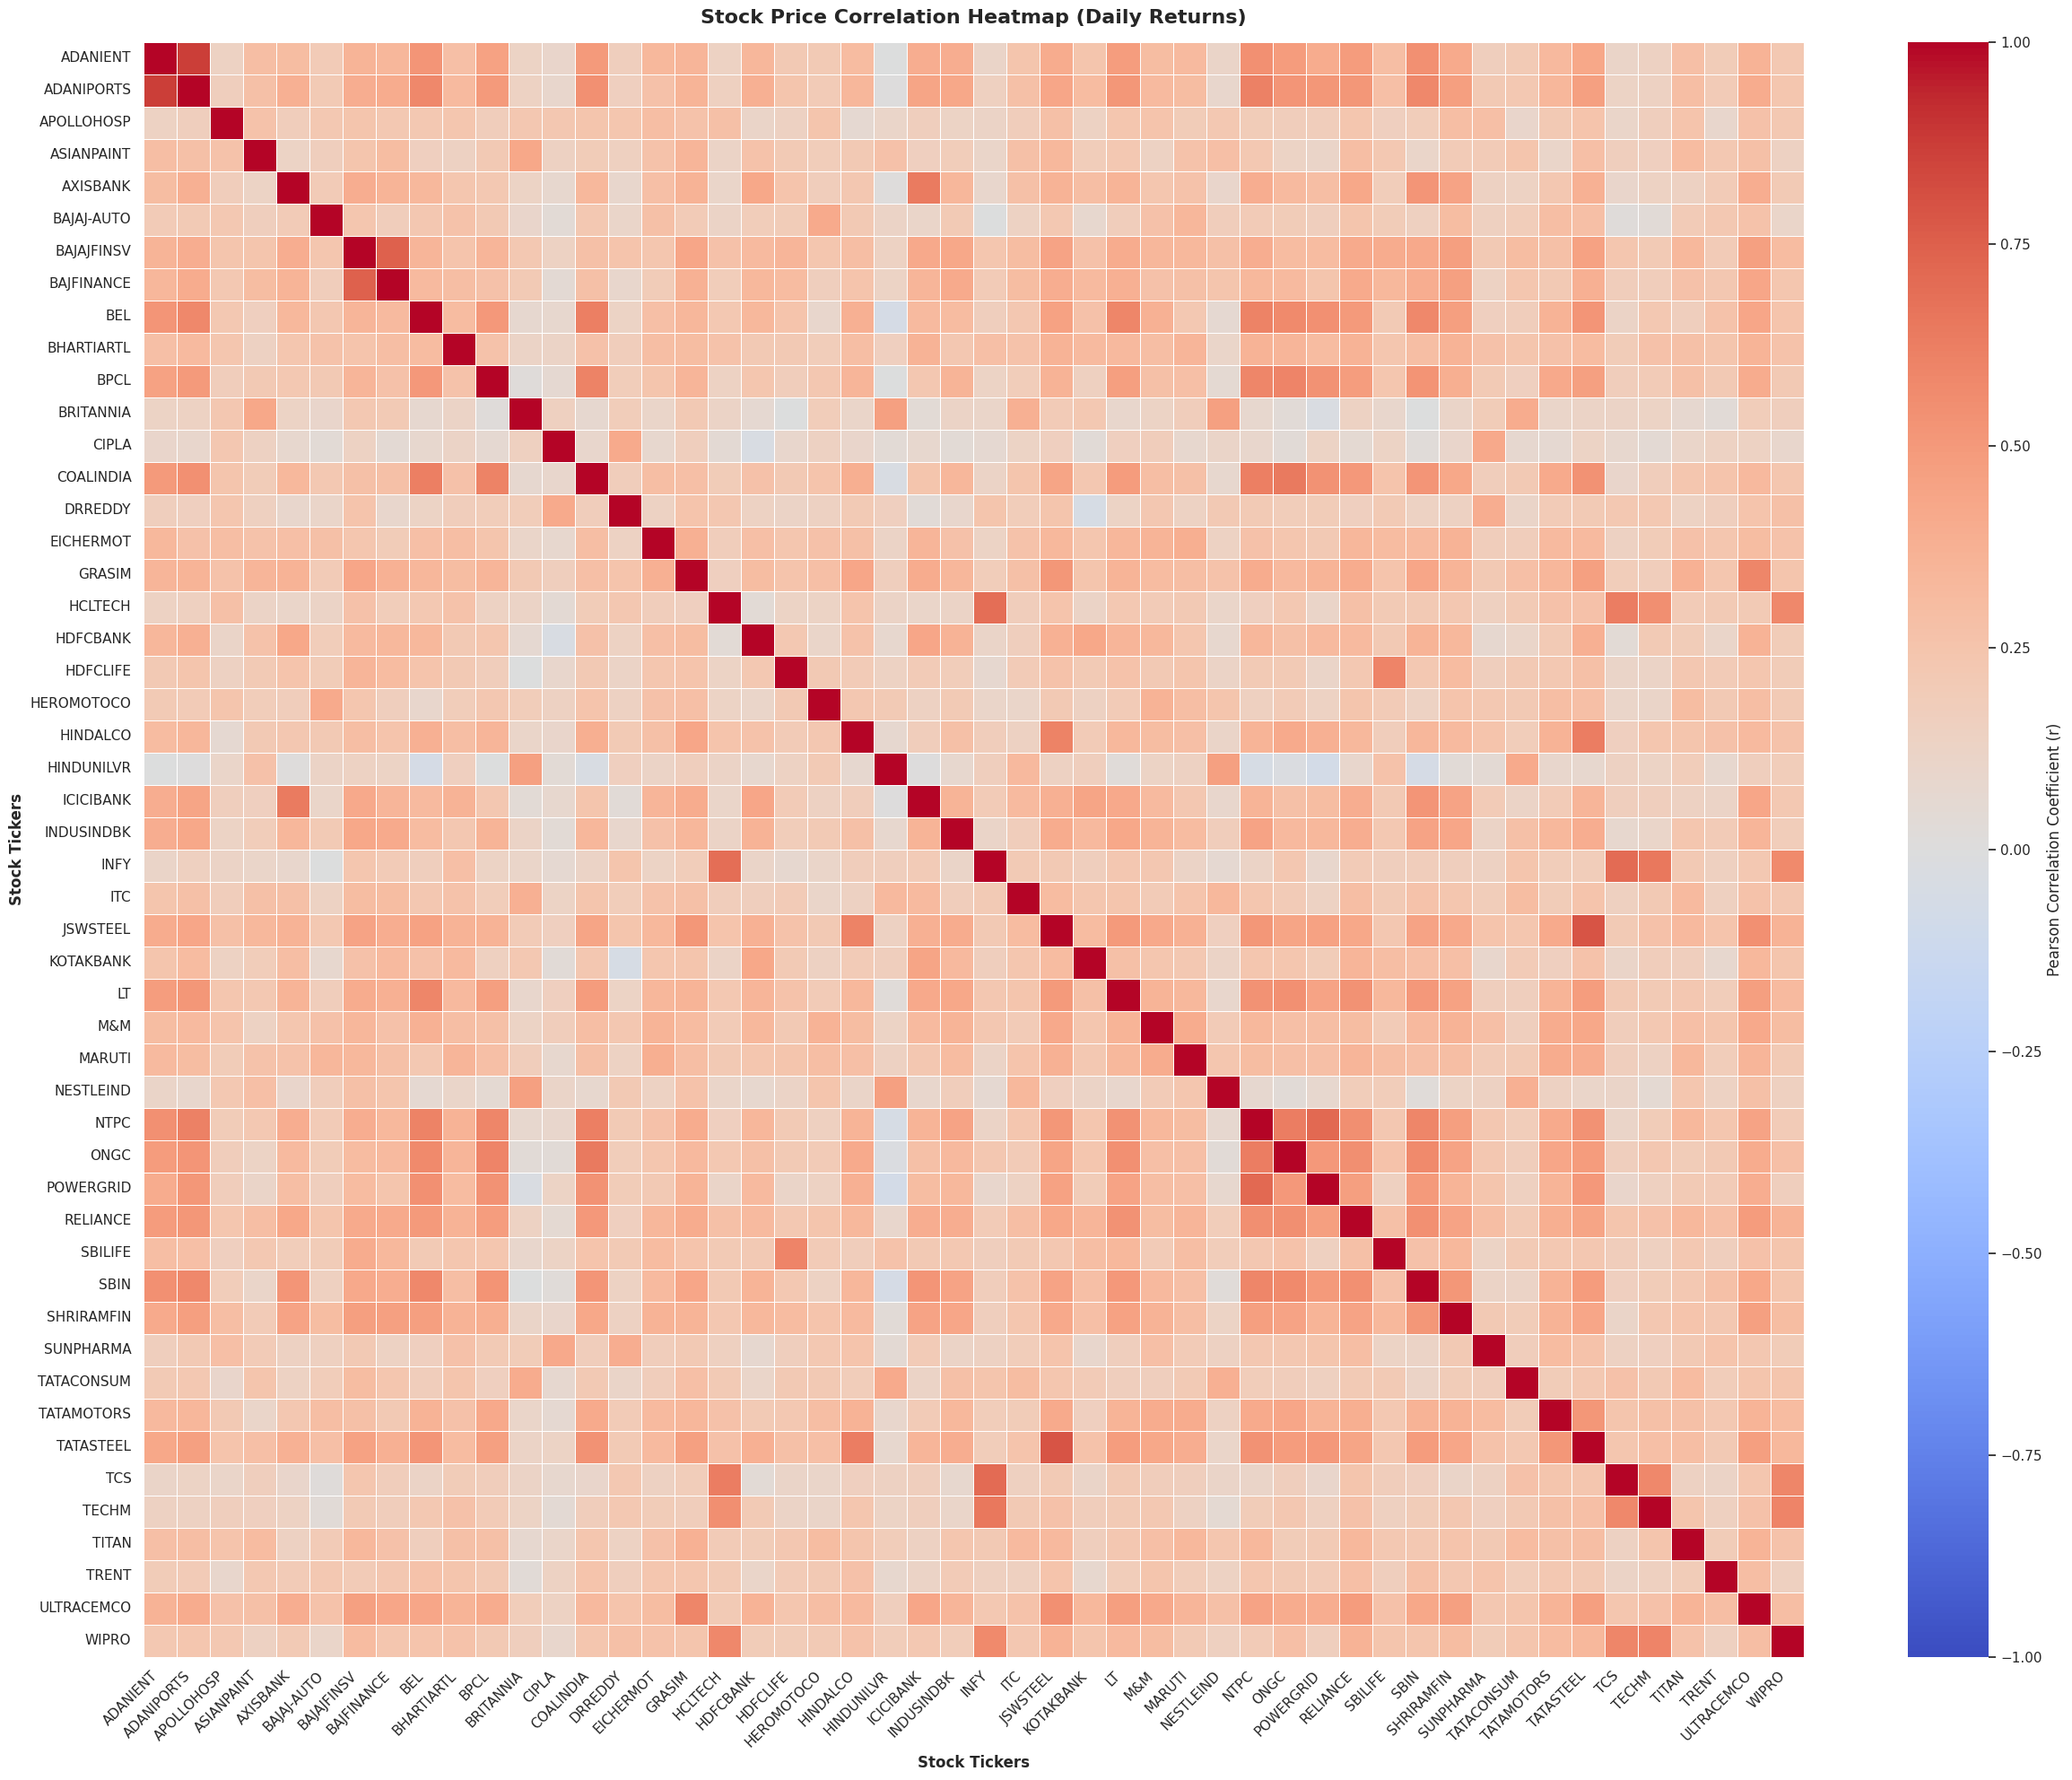

In [ ]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

csv_directory = '/content/drive/MyDrive/Classroom/stock_csvs'
output_directory = '/content/drive/MyDrive/Classroom/analysis_outputs'
os.makedirs(output_directory, exist_ok=True)

csv_files = glob.glob(os.path.join(csv_directory, "*.csv"))

if not csv_files:
    print(f"❌ ERROR: No CSV files found in '{csv_directory}'.")
else:
    # Combine and structure data into a pivot table
    list_of_dfs = []
    for file_path in csv_files:
        df_stock = pd.read_csv(file_path)
        # Ensure correct column naming and data type tracking
        if 'Symbol' in df_stock.columns and 'Date' in df_stock.columns and 'Close' in df_stock.columns:
            list_of_dfs.append(df_stock[['Date', 'Symbol', 'Close']])

    df_combined = pd.concat(list_of_dfs, ignore_index=True)
    df_combined['Date'] = pd.to_datetime(df_combined['Date'])

    # Pivot data so that each column is a unique Stock Ticker and rows are historical dates
    df_pivot = df_combined.pivot(index='Date', columns='Symbol', values='Close')

    print("🔄 Processing daily performance movements...")

    # Calculate daily percentage changes (returns) to remove raw price scale bias
    df_daily_returns = df_pivot.pct_change().dropna(how='all')

    # Generate the Correlation Matrix using Pearson method
    correlation_matrix = df_daily_returns.corr(method='pearson')
    path_corr_csv = os.path.join(output_directory, 'market_stock_correlation_matrix.csv')
    correlation_matrix.to_csv(path_corr_csv)
    print(f"💾 Success! Complete correlation matrix saved to: {path_corr_csv}")

    num_stocks = len(correlation_matrix.columns)
    plt.figure(figsize=(max(12, num_stocks * 0.5), max(10, num_stocks * 0.4)))
    sns.set_theme(style="white")

    # Drawing the heatmap using a clean diverging color palette (coolwarm)
    # 1.0 = Perfectly positively correlated (Dark Red)
    # 0.0 = No correlation (White/Light Neutral)
    # -1.0 = Perfectly negatively correlated (Dark Blue)
    ax = sns.heatmap(
        correlation_matrix,
        annot=(num_stocks <= 20),  # Only show exact numbers if matrix is small enough to read
        fmt=".2f",
        cmap='coolwarm',
        vmin=-1.0,
        vmax=1.0,
        linewidths=0.5,
        cbar_kws={"label": "Pearson Correlation Coefficient (r)"}
    )

    plt.title('Stock Price Correlation Heatmap (Daily Returns)', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Stock Tickers', fontsize=12, fontweight='bold')
    plt.ylabel('Stock Tickers', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()

    # 💾 SAVE HEATMAP AS PNG IMAGE
    chart_corr_path = os.path.join(output_directory, 'stock_correlation_heatmap.png')
    plt.savefig(chart_corr_path, dpi=300)
    print(f"🖼️ Success! Heatmap visual saved as PNG image to: {chart_corr_path}\n")

    plt.show()


**Stock Price Return Correlation Heatmap (Top 10 Green Stocks)**


🔄 Constructing historical price correlation models...
💾 Success! Full correlation matrix table saved to: market_price_correlation_matrix1.csv


/tmp/ipykernel_7199/2478369375.py:47: UserWarning: Glyph 128306 (\N{BLACK SQUARE BUTTON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7199/2478369375.py:51: UserWarning: Glyph 128306 (\N{BLACK SQUARE BUTTON}) missing from font(s) DejaVu Sans.
  plt.savefig(chart_heatmap_path, dpi=300)


🖼️ Success! Correlation heatmap visual saved to: /content/drive/MyDrive/Classroom/analysis_outputs/stock_price_correlation_heatmap1.png



/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128306 (\N{BLACK SQUARE BUTTON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


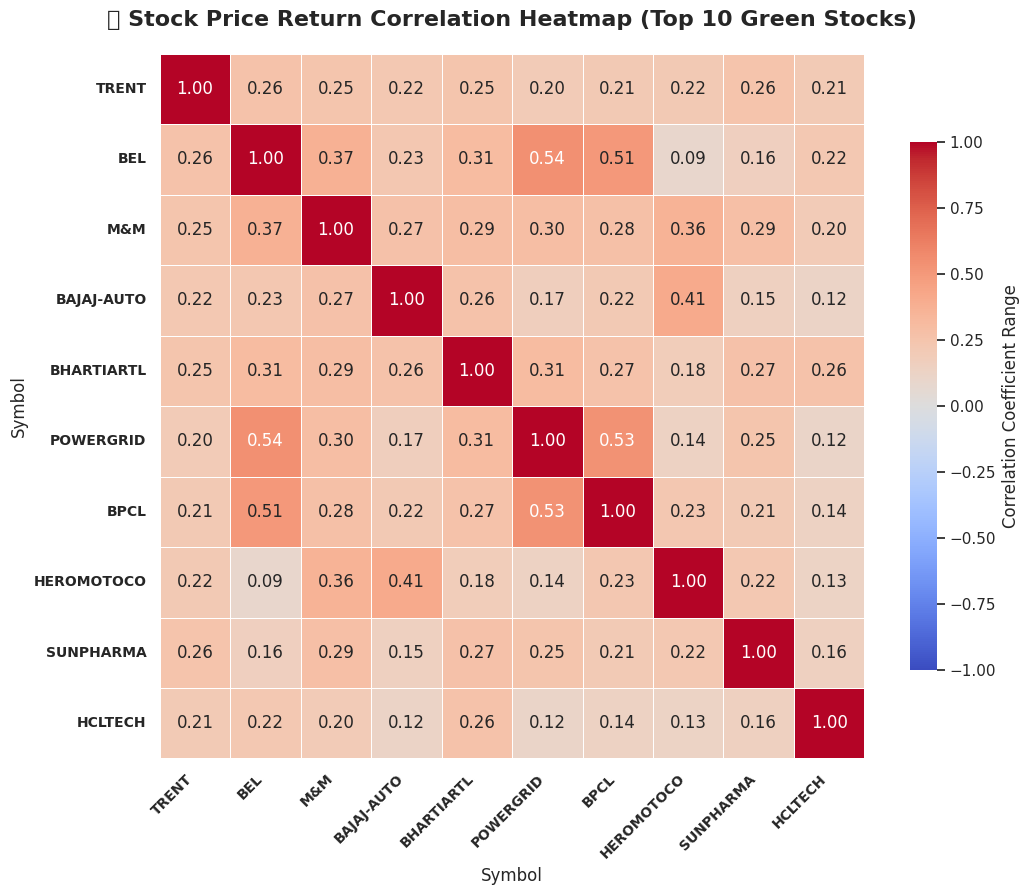

In [ ]:
rint("🔄 Constructing historical price correlation models...")

# Pivot the dataset into a time-series grid (Rows = Dates, Columns = Stock Symbols)
df_price_pivot = df_master.pivot(index='Date', columns='Symbol', values='Close')

#Calculated daily percentage changes to ensure correlation is based on return movement, not price scale
df_daily_returns_pct = df_price_pivot.pct_change().dropna(how='all')

#Applied the pandas.DataFrame.corr() method to build the global Pearson correlation matrix
df_full_correlation_matrix = df_daily_returns_pct.corr()
path_correlation_csv = os.path.join(output_directory, 'market_price_correlation_matrix1.csv')
df_full_correlation_matrix.to_csv(path_correlation_csv)
print(f"💾 Success! Full correlation matrix table saved to: {os.path.basename(path_correlation_csv)}")

# 4. Filtered for a 10x10 subset (using your Top 10 Green stocks) to keep the heatmap clean and readable
visualization_subset_symbols = top_10_green['Symbol'].tolist()
df_heatmap_subset = df_full_correlation_matrix.loc[visualization_subset_symbols, visualization_subset_symbols]


plt.figure(figsize=(11, 9))
sns.set_theme(style="white")
sns.heatmap(
    df_heatmap_subset,
    annot=True,               # Display correlation coefficient values inside each square
    cmap='coolwarm',          # Darker red = high positive correlation, Darker blue = negative correlation
    fmt=".2f",                # Limit decimal outputs to 2 places
    vmin=-1, vmax=1,          # Force strict standard financial bounds limits
    square=True,              # Lock cells into perfect squares
    linewidths=.7,            # Draw subtle grid borders between cells
    cbar_kws={"shrink": .75, "label": "Correlation Coefficient Range"}
)

# Polish titles, label alignments, and canvas formatting
plt.title('🔲 Stock Price Return Correlation Heatmap (Top 10 Green Stocks)', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontweight='bold', fontsize=10)
plt.yticks(rotation=0, fontweight='bold', fontsize=10)

plt.tight_layout()
chart_heatmap_path = os.path.join(output_directory, 'stock_price_correlation_heatmap1.png')
plt.savefig(chart_heatmap_path, dpi=300)
print(f"🖼️ Success! Correlation heatmap visual saved to: {chart_heatmap_path}\n")

plt.show()


**Top 5 Gainers and Losers (Month-wise)**

🔄 Processing granular month-by-month return matrix...
💾 Success! Compiled monthly records saved to: /content/drive/MyDrive/Classroom/analysis_outputs/monthly_top_gainers_and_losers.csv
🎨 Generating 12-Month Dashboard Grid visual. Please wait...


/tmp/ipykernel_7199/2731379340.py:136: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7199/2731379340.py:140: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig(chart_dashboard_path, dpi=200, bbox_inches='tight')


🖼️ Success! Complete dashboard grid saved as PNG to: /content/drive/MyDrive/Classroom/analysis_outputs/monthly_performance_dashboard.png



/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


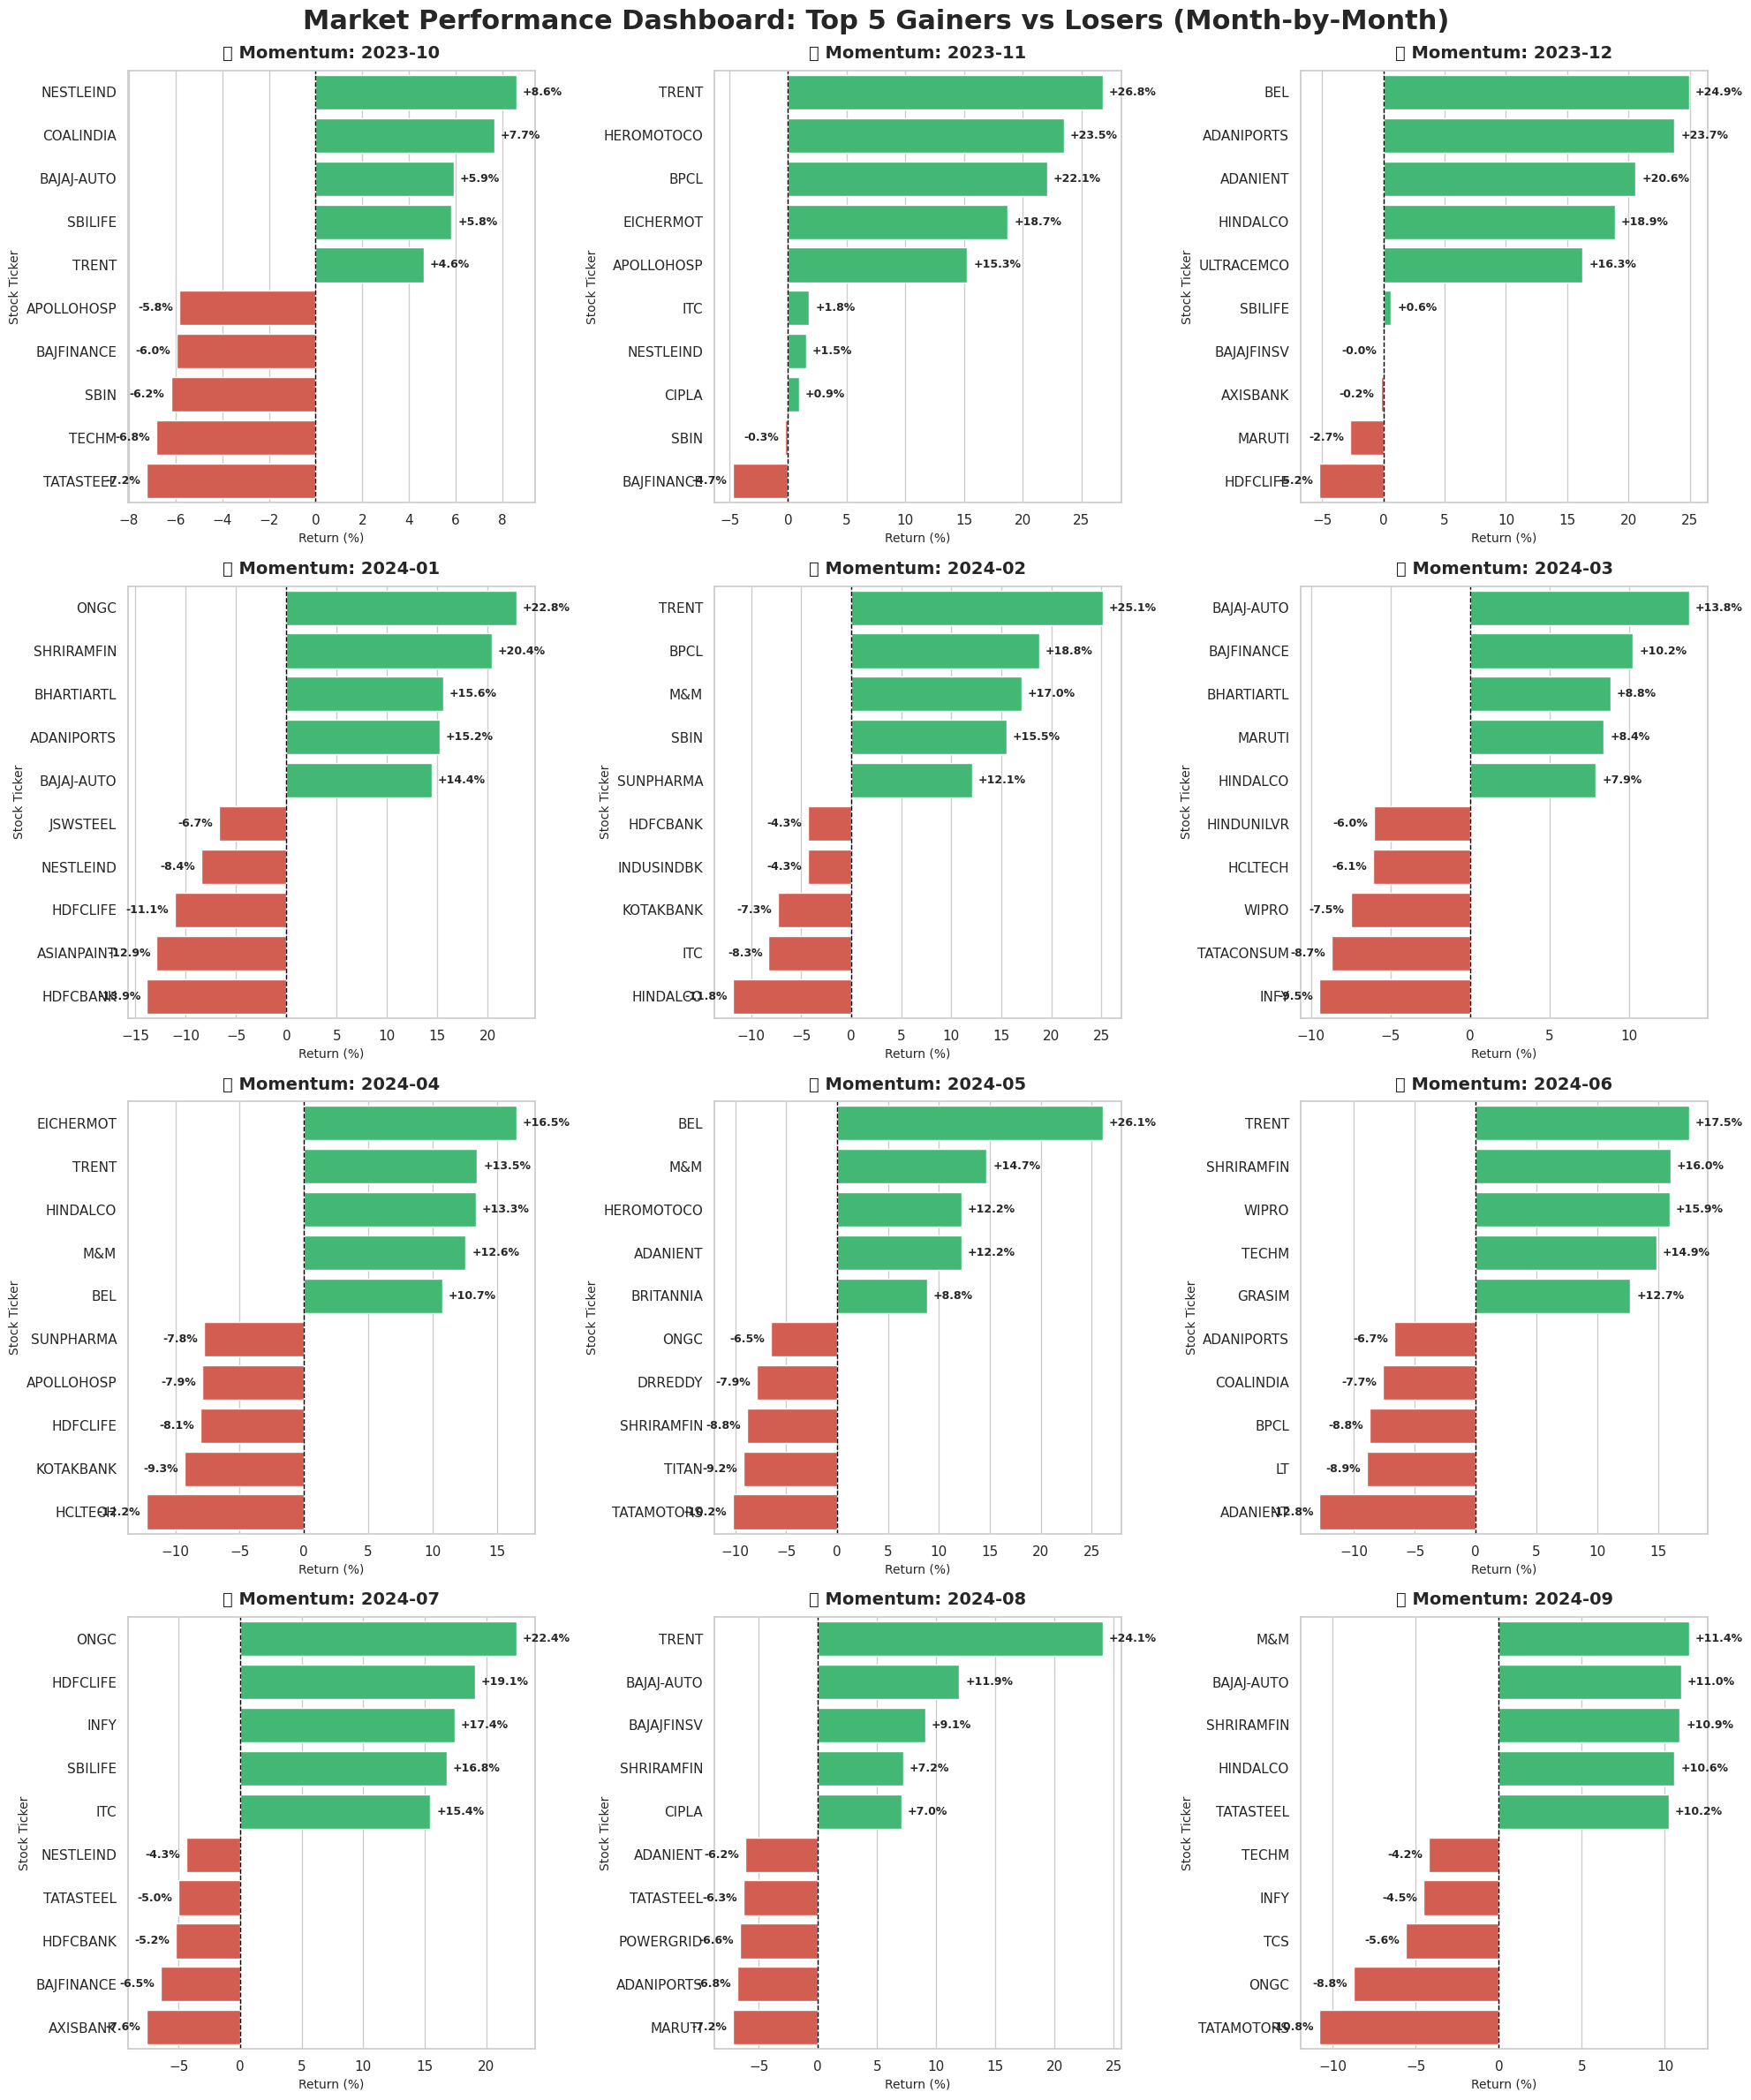

In [ ]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

csv_directory = '/content/drive/MyDrive/Classroom/stock_csvs'
output_directory = '/content/drive/MyDrive/Classroom/analysis_outputs'
os.makedirs(output_directory, exist_ok=True)

csv_files = glob.glob(os.path.join(csv_directory, "*.csv"))

if not csv_files:
    print(f"❌ ERROR: No CSV files found in '{csv_directory}'.")
else:
    list_of_dfs = []
    for file_path in csv_files:
        list_of_dfs.append(pd.read_csv(file_path))

    df_master = pd.concat(list_of_dfs, ignore_index=True)
    df_master['Date'] = pd.to_datetime(df_master['Date'])
    df_master = df_master.sort_values(by=['Symbol', 'Date']).reset_index(drop=True)

    print("🔄 Processing granular month-by-month return matrix...")

    # Extract Year-Month tracking stamps
    df_master['Year_Month'] = df_master['Date'].dt.to_period('M')

    # Calculate monthly returns per symbol using chronological first and last entries
    monthly_performance = []
    for (symbol, period), group in df_master.groupby(['Symbol', 'Year_Month']):
        first_close = group['Close'].iloc[0]
        last_close = group['Close'].iloc[-1]

        monthly_return = ((last_close - first_close) / first_close) * 100 if first_close > 0 else 0.0
        monthly_performance.append({
            'Year_Month': period,
            'Symbol': symbol,
            'Monthly_Return_%': round(monthly_return, 2)
        })

    df_monthly = pd.DataFrame(monthly_performance)

    #Loop sequentially through unique months to rank gainers and losers
    all_months = sorted(df_monthly['Year_Month'].unique())

    dashboard_records = []
    for month in all_months:
        df_month_pool = df_monthly[df_monthly['Year_Month'] == month]

        # Pull top 5 gainers and bottom 5 losers
        top_5 = df_month_pool.sort_values(by='Monthly_Return_%', ascending=False).head(5).copy()
        bot_5 = df_month_pool.sort_values(by='Monthly_Return_%', ascending=True).head(5).copy()

        top_5['Type'] = 'Gainer'
        bot_5['Type'] = 'Loser'

        dashboard_records.append(top_5)
        dashboard_records.append(bot_5)

    # Compiled the filtered leaders table
    df_dashboard_master = pd.concat(dashboard_records, ignore_index=True)
    # Converted period back to string format for simple clean CSV saving
    df_dashboard_master['Year_Month'] = df_dashboard_master['Year_Month'].astype(str)

    path_monthly_csv = os.path.join(output_directory, 'monthly_top_gainers_and_losers.csv')
    df_dashboard_master.to_csv(path_monthly_csv, index=False)
    print(f"💾 Success! Compiled monthly records saved to: {path_monthly_csv}")

    print("🎨 Generating 12-Month Dashboard Grid visual. Please wait...")
    sns.set_theme(style="whitegrid")

    # Created a 4x3 subplot structure grid layout (12 subplots total)
    fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(20, 24))
    axes = axes.flatten()
    for idx, month in enumerate(all_months):
        if idx >= len(axes):
            break

        ax = axes[idx]

        # Filter metrics for this target plot instance
        df_plot_pool = df_dashboard_master[df_dashboard_master['Year_Month'] == str(month)]

        # Combine top and bottom items into one sorted sequence for unified display
        df_plot_sorted = df_plot_pool.sort_values(by='Monthly_Return_%', ascending=False)

        # Create a dynamic color profile: Green for gainers, Red for losers
        colors = ['#2ecc71' if val >= 0 else '#e74c3c' for val in df_plot_sorted['Monthly_Return_%']]

        # Build horizontal bar plot for easily scanning stock ticker labels
        sns.barplot(
            x='Monthly_Return_%',
            y='Symbol',
            data=df_plot_sorted,
            palette=colors,
            hue='Symbol',
            legend=False,
            ax=ax
        )

        # Set individual monthly chart properties
        ax.set_title(f"📈 Momentum: {month}", fontsize=14, fontweight='bold', pad=10)
        ax.set_xlabel('Return (%)', fontsize=10)
        ax.set_ylabel('Stock Ticker', fontsize=10)
        ax.axvline(0, color='black', linewidth=1, linestyle='--')

        # Add value numbers right on the tips of the bars
        for p in ax.patches:
            width = p.get_width()
            ha_align = 'left' if width >= 0 else 'right'
            xy_offset = (5, 0) if width >= 0 else (-5, 0)

            ax.annotate(
                f"{width:+.1f}%",
                (width, p.get_y() + p.get_height() / 2.),
                ha=ha_align, va='center',
                xytext=xy_offset,
                textcoords='offset points',
                fontsize=9, fontweight='bold'
            )

    # Hide any unused subplots out of the 12 spaces if your dataset covers less time
    for unused_idx in range(len(all_months), len(axes)):
        fig.delaxes(axes[unused_idx])

    plt.suptitle('Market Performance Dashboard: Top 5 Gainers vs Losers (Month-by-Month)',
                 fontsize=22, fontweight='bold', y=0.99)
    plt.tight_layout()

    # 💾 SAVE DASHBOARD VISUAL AS PNG IMAGE
    chart_dashboard_path = os.path.join(output_directory, 'monthly_performance_dashboard.png')
    plt.savefig(chart_dashboard_path, dpi=200, bbox_inches='tight')
    print(f"🖼️ Success! Complete dashboard grid saved as PNG to: {chart_dashboard_path}\n")

    plt.show()


**SQL Database**

In [2]:
import os
import glob
import sqlite3
import pandas as pd

def store_analysis_outputs_in_sql(output_directory, db_filename="nifty50_market_data.db"):
    """
    Scans the analysis_outputs directory for generated result CSV files,
    cleans up their names, and writes them into separate tables in the SQLite database.
    """
    db_file_path = os.path.join(output_directory, db_filename)

    # Verify database existence
    if not os.path.exists(db_file_path):
        print(f"❌ ERROR: Target database file not found at: '{db_file_path}'")
        print("Please ensure your master stock table ingestion step ran successfully first.")
        return

    #Established connection  SQLite database
    print(f"📦 Connecting to SQLite database at: {db_file_path}")
    connection = sqlite3.connect(db_file_path)

    #Located all analytical summary CSVs in the output directory
    csv_files = glob.glob(os.path.join(output_directory, "*.csv"))
    if not csv_files:
        print(f"❌ ERROR: No analysis output CSV files found in '{output_directory}'.")
        connection.close()
        return

    print(f"📁 Identified {len(csv_files)} summary data sheets for SQL storage. Processing...")

    for file_path in csv_files:
        file_name = os.path.basename(file_path)

        if file_name == '/content/drive/MyDrive/Classroom/analysis_outputs/sector.csv':
            continue

        try:
            table_name = "tbl_" + file_name.replace('.csv', '').replace(' ', '_').lower()

            df_insight = pd.read_csv(file_path)


            df_insight.to_sql(
                name=table_name,
                con=connection,
                if_exists='replace',
                index=False
            )
            print(f"  🟩 Successfully wrote table '{table_name}' ({len(df_insight)} rows)")

        except Exception as e:
            print(f"  ⚠️ Failed to write file '{file_name}' to SQL table. Details: {e}")

    connection.commit()
    connection.close()
    print("\n✨ Success! All business analysis outputs are now stored as relational tables inside your SQLite database.")

store_analysis_outputs_in_sql(
    output_directory='/content/drive/MyDrive/Classroom/analysis_outputs'
)


📦 Connecting to SQLite database at: /content/drive/MyDrive/Classroom/analysis_outputs/nifty50_market_data.db
📁 Identified 10 summary data sheets for SQL storage. Processing...
  🟩 Successfully wrote table 'tbl_sector' (50 rows)
  🟩 Successfully wrote table 'tbl_overall_market_summary' (1 rows)
  🟩 Successfully wrote table 'tbl_top_10_most_volatile_stocks' (10 rows)
  🟩 Successfully wrote table 'tbl_top_10_loss_stocks' (10 rows)
  🟩 Successfully wrote table 'tbl_top_10_green_stocks' (10 rows)
  🟩 Successfully wrote table 'tbl_top_5_cumulative_returns_timeline' (1420 rows)
  🟩 Successfully wrote table 'tbl_sector_wise_performance_summary' (21 rows)
  🟩 Successfully wrote table 'tbl_market_stock_correlation_matrix' (50 rows)
  🟩 Successfully wrote table 'tbl_market_price_correlation_matrix1' (50 rows)
  🟩 Successfully wrote table 'tbl_monthly_top_gainers_and_losers' (140 rows)

✨ Success! All business analysis outputs are now stored as relational tables inside your SQLite database.


In [3]:
db_path = '/content/drive/MyDrive/Classroom/analysis_outputs/nifty50_market_data.db'
conn = sqlite3.connect(db_path)
tables_df = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)
print("📊 Current Tables inside your SQLite Database File:")
print(tables_df)

conn.close()


📊 Current Tables inside your SQLite Database File:
                                     name
0                            stock_prices
1                              tbl_sector
2              tbl_overall_market_summary
3         tbl_top_10_most_volatile_stocks
4                  tbl_top_10_loss_stocks
5                 tbl_top_10_green_stocks
6   tbl_top_5_cumulative_returns_timeline
7     tbl_sector_wise_performance_summary
8     tbl_market_stock_correlation_matrix
9    tbl_market_price_correlation_matrix1
10     tbl_monthly_top_gainers_and_losers


STREAMLIT

In [ ]:
!pip install -q streamlit pymysql sqlalchemy pandas matplotlib seaborn
!npm install -g localtunnel


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 57.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.7/45.7 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 73.6 MB/s eta 0:00:00
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸
added 22 packages in 3s
⠸
⠸3 packages are looking for funding
⠸  run `npm fund` for details
⠸

In [ ]:
%%writefile app.py
from numpy import nancumprod
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import math
import os

st.set_page_config(
    page_title="Nifty 50 Market Performance Dashboard",
    page_icon="📈",
    layout="wide"
)

DB_FILENAME = '/content/drive/MyDrive/Classroom/analysis_outputs/nifty50_market_data.db'

def get_db_connection():
    """Establishes a safe connection to your pre-existing SQLite database file."""
    if not os.path.exists(DB_FILENAME):
        st.error(f"❌ Database file '{DB_FILENAME}' not found in the current working directory. Please ensure it is uploaded.")
        st.stop()
    return sqlite3.connect(DB_FILENAME)

st.title("📈 Data-Driven Stock Analysis Dashboard")

conn = get_db_connection()

tab_overview, tab_volatility, tab_growth, tab_sector, tab_correlation, tab_monthly = st.tabs([
    "📊 Market Overview", "⚡ Volatility Analysis", "📈 Cumulative Return",
    "🏢 Sector Performance", "🔲 Stock Price Correlations", "📅 Month-wise Breakdown"
])

with tab_overview:
    st.subheader("📊 Core Market Parameters & Standings")

    try:
        df_summary = pd.read_sql_query("SELECT * FROM tbl_overall_market_summary;", conn)
        if not df_summary.empty:
            row = df_summary.iloc[0]

            m1, m2, m3, m4, m5 = st.columns(5)
            m1.metric("Total Stocks Analyzed", int(row.get('Total_Stocks_Analyzed', 0)))
            m2.metric("Green Stocks Count", f"{int(row.get('Green_Stocks_Count', 0))}", f"{row.get('Green_Stocks_Percentage', 0)}%")
            m3.metric("Red Stocks Count", f"{int(row.get('Red_Stocks_Count', 0))}", f"-{row.get('Red_Stocks_Percentage', 0)}%", delta_color="inverse")
            m4.metric("Avg Market Price", f"₹ {round(row.get('Average_Market_Price', 0), 2)}")
            m5.metric("Avg Market Volume", f"{int(row.get('Average_Market_Volume', 0)):,}")
    except Exception as e:
        st.warning(f"Could not load overall market summary table. Details: {e}")

    st.markdown("---")
    l1, l2 = st.columns(2)

    with l1:
        st.markdown("### 🟢 Top 10 Best-Performing Stocks")
        try:
            df_green = pd.read_sql_query("SELECT * FROM tbl_top_10_green_stocks ORDER BY [Yearly_Return_%] DESC;", conn)
            st.dataframe(df_green, use_container_width=True, hide_index=True)
        except Exception as e:
            st.error(f"Error loading green stocks table: {e}")

    with l2:
        st.markdown("### 🔴 Top 10 Worst-Performing Stocks")
        try:
            df_loss = pd.read_sql_query("SELECT * FROM tbl_top_10_loss_stocks ORDER BY [Yearly_Return_%] ASC;", conn)
            st.dataframe(df_loss, use_container_width=True, hide_index=True)
        except Exception as e:
            st.error(f"Error loading loss stocks table: {e}")

# ------------------------------------------
# TAB 2: VOLATILITY ANALYSIS
# ------------------------------------------
with tab_volatility:
    st.subheader("⚡ Volatility Leaderboard (Standard Deviation of Daily Returns)")

    try:
        df_vol = pd.read_sql_query("SELECT * FROM tbl_top_10_most_volatile_stocks ORDER BY Volatility_StdDev DESC;", conn)

        v_col1, v_col2 = st.columns([2, 3])
        with v_col1:
            st.markdown("#### High-Risk Asset Summary")
            st.dataframe(df_vol, use_container_width=True, hide_index=True)
        with v_col2:
            fig, ax = plt.subplots(figsize=(10, 5.5))
            sns.set_theme(style="whitegrid")
            sns.barplot(x='Symbol', y='Volatility_StdDev', data=df_vol, palette='flare', hue='Symbol', legend=False, ax=ax)
            plt.title('Top 10 Most Volatile Stocks Over the Year', fontsize=12, fontweight='bold')
            plt.xticks(rotation=45, ha='right')
            st.pyplot(fig)
    except Exception as e:
        st.error(f"Error executing volatility models: {e}")

# ------------------------------------------
# TAB 3: CUMULATIVE RETURN OVER TIME
# ------------------------------------------
with tab_growth:
    st.subheader("📈 Cumulative Return Progression (Top 5 Performing Assets)")

    try:
        df_growth = pd.read_sql_query("SELECT * FROM tbl_top_5_cumulative_returns_timeline;", conn)
        df_growth['Date'] = pd.to_datetime(df_growth['Date'])
        df_growth = df_growth.sort_values(by=['Symbol', 'Date'])

        g_col1, g_col2 = st.columns([1, 2])
        with g_col1:
            st.markdown("#### Top 5 Performance Trajectory")
            st.markdown("This line chart reflects the continuous rolling compound growth values tracked from day 1 to the end of the trading timeline window.")

            df_finals = df_growth.groupby('Symbol').last().reset_index()
            st.dataframe(df_finals[['Symbol', 'Cumulative_Return_%']].sort_values(by='Cumulative_Return_%', ascending=False), use_container_width=True, hide_index=True)

        with g_col2:
            fig, ax = plt.subplots(figsize=(12, 5.5))
            sns.set_theme(style="whitegrid")
            sns.lineplot(data=df_growth, x='Date', y='Cumulative_Return_%', hue='Symbol', palette='tab10', linewidth=2.5, ax=ax)
            plt.title('Cumulative Return Progression of Top 5 Performing Stocks', fontsize=12, fontweight='bold')
            plt.ylabel('Cumulative Return (%)')
            plt.xlabel('Timeline / Date')
            plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
            st.pyplot(fig)
    except Exception as e:
        st.error(f"Error mapping timeline metrics: {e}")

# ------------------------------------------
# TAB 4: SECTOR-WISE PERFORMANCE
# ------------------------------------------
with tab_sector:
    st.subheader("🏢 Performance Breakdown by Industry Sector")

    try:
        df_sector = pd.read_sql_query("SELECT * FROM tbl_sector_wise_performance_summary ORDER BY [Yearly_Return_%] DESC;", conn)

        s_col1, s_col2 = st.columns([2, 3])
        with s_col1:
            st.markdown("#### Industry Sectors Standings")
            st.dataframe(df_sector, use_container_width=True, hide_index=True)
        with s_col2:
            fig, ax = plt.subplots(figsize=(10, 5.5))
            sns.set_theme(style="whitegrid")
            sns.barplot(x='Sector', y='Yearly_Return_%', data=df_sector, palette='viridis', hue='Sector', legend=False, ax=ax)
            plt.title('Average Yearly Return by Industry Sector', fontsize=12, fontweight='bold')
            plt.xticks(rotation=35, ha='right')
            plt.axhline(0, color='black', linewidth=1, linestyle='--')
            st.pyplot(fig)
    except Exception as e:
        st.error(f"Error accessing industry sector matrices: {e}")

# ------------------------------------------
# TAB 5: STOCK PRICE CORRELATION
# ------------------------------------------
with tab_correlation:
    st.subheader("🔲 Asset Return Inter-Correlation Heatmaps")

    matrix_table = "tbl_market_price_correlation_matrix1"
    try:
        df_corr_raw = pd.read_sql_query(f"SELECT * FROM {matrix_table};", conn)

        if 'Symbol' in df_corr_raw.columns:
            df_corr_raw = df_corr_raw.set_index('Symbol')
        elif 'index' in df_corr_raw.columns:
            df_corr_raw = df_corr_raw.set_index('index')
        else:
            first_col = df_corr_raw.columns[0]
            df_corr_raw = df_corr_raw.set_index(first_col)

        # Ensure all values inside our operational block are typed numeric float values
        df_corr = df_corr_raw.apply(pd.to_numeric, errors='coerce')

        # Limit visualization subset size to the top 10 green stocks to prevent color box crowding
        try:
            top_10_green_list = pd.read_sql_query("SELECT Symbol FROM tbl_top_10_green_stocks LIMIT 10;", conn)['Symbol'].tolist()
            safe_symbols = [sym for sym in top_10_green_list if sym in df_corr.columns]
        except:
            safe_symbols = df_corr.columns[:10].tolist()

        if len(safe_symbols) < 2:
            st.warning("Insufficient metrics overlap to compile heatmap correlation matrices safely.")
        else:
            df_heat_subset = df_corr.loc[safe_symbols, safe_symbols]

            fig, ax = plt.subplots(figsize=(10, 8))
            sns.heatmap(df_heat_subset, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
            plt.title('Stock Price Return Correlation Heatmap (Top 10 Green Stocks)', fontsize=12, fontweight='bold', pad=10)
            st.pyplot(fig)

    except Exception as e:
        st.error(f"Error loading matrix grids: {e}")

# ------------------------------------------
# TAB 6: TOP 5 GAINERS AND LOSERS (MONTH-WISE)
# ------------------------------------------
with tab_monthly:
    st.subheader("📅 Month-by-Month Performance Grid Dashboard")
    try:
        df_monthly = pd.read_sql_query("SELECT * FROM tbl_monthly_top_gainers_and_losers;", conn)

        if 'Type' not in df_monthly.columns:
            df_monthly['Type'] = ['Gainer' if v >= 0 else 'Loser' for v in df_monthly['Monthly_Return_%']]

        all_months = sorted(df_monthly['Year_Month'].unique())

        if len(all_months) == 0:
            st.warning("No tracking months identified inside the monthly dashboard table records.")
        else:
            num_cols = 3
            num_rows = math.ceil(len(all_months) / num_cols)
            fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(20, 5.2 * num_rows))

            if len(all_months) == 1:
                axes = [axes]
            else:
                axes = axes.flatten()

            for idx, month in enumerate(all_months):
                ax = axes[idx]
                df_plot = df_monthly[df_monthly['Year_Month'] == month].sort_values(by='Monthly_Return_%', ascending=False)

                color_map = {'Gainer': '#2ecc71', 'Loser': '#e74c3c'}

                sns.barplot(
                    x='Monthly_Return_%',
                    y='Symbol',
                    data=df_plot,
                    palette=color_map,
                    hue='Type',
                    legend=False,
                    ax=ax
                )

                for p in ax.patches:
                    width = p.get_width()
                    if not math.isnan(width):
                        ha_align = 'left' if width >= 0 else 'right'
                        xy_offset = (5, 0) if width >= 0 else (-5, 0)
                        ax.annotate(
                            f"{width:+.1f}%",
                            (width, p.get_y() + p.get_height() / 2.),
                            ha=ha_align, va='center',
                            xytext=xy_offset,
                            textcoords='offset points',
                            fontsize=9, fontweight='bold'
                        )

                ax.set_title(f"📈 Momentum: {month}", fontweight='bold', fontsize=12)
                ax.set_xlabel('Return (%)', fontsize=9)
                ax.set_ylabel('Ticker Symbol', fontsize=9)
                ax.axvline(0, color='black', linewidth=1, linestyle='--')
            for i in range(len(all_months), len(axes)):
                fig.delaxes(axes[i])

            plt.tight_layout()
            st.pyplot(fig)
            plt.close(fig) # Frees backend image cache memory allocations

    except Exception as e:
        st.error(f"Error creating monthly chart subplots matrix grid: {e}")

    conn.close()


Writing app.py


In [ ]:
!streamlit run app.py &>/content/logs.txt & npx localtunnel --port 8501


⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧your url is: https://clever-emus-raise.loca.lt
^C
